# Additional Feature Occlusion

In [4]:
import xarray as xr
from pkg.plots.feature_occlusion_plots import plot_mean_wind_speed_comparison_feature_occlusion, plot_feature_grouped_heatmap, plot_feature_grouped_heatmap_special_for_pressure_level
from pkg.feature_occlusion.forecast_with_mask import run_multiple_forecasts_with_mask

# Run Feature Occlusion

In [3]:
input_path = "../data/graphcast_small/graphcast_small_zeynep_input/graphcast_ready_input_graphcast_small_zeynep_input.nc"
input = xr.open_dataset(input_path)

climatology_path = "../data/data_for_climatology/era5_1979-2015_0218_climatology.nc"
climatology = xr.open_dataset(climatology_path)

In [ ]:
surface_variables = [
    "2m_temperature",
    ("10m_u_component_of_wind",
    "10m_v_component_of_wind"),
    "total_precipitation_6hr",
    "mean_sea_level_pressure",
]

atmospheric_variables = [
    "temperature",
    ("u_component_of_wind",
    "v_component_of_wind"),
    "geopotential",
    "vertical_velocity",
    "specific_humidity",
]

lower_troposphere = (850, 925, 1000)
mid_troposphere = (500, 600, 700)
upper_troposphere = (250, 300, 400)
stratospheric_levels  = (50, 100, 150, 200)

pressure_level_groups = [
    lower_troposphere,
    mid_troposphere,
    upper_troposphere,
    stratospheric_levels,
]

pressure_levels = [
    1000, 925, 850, 700, 600, 500, 400, 300, 250, 200, 150, 100, 50
]

regions = [
    "atlantic_jet_stream",
    "storm_core",
    "dynamic_uljs",
    "high_pressure_south",
    "low_pressure_north",
]


### Pressure Level Zones

In [ ]:
run_multiple_forecasts_with_mask(
    input_data=input,
    climatology=climatology,
    predictions_folder="../data/feature_occlusion/pressure_level_groups",
    pressure_levels=pressure_level_groups
)

### All pressure Levels

In [ ]:
run_multiple_forecasts_with_mask(
    input_data=input,
    climatology=climatology,
    predictions_folder="../data/feature_occlusion/pressure_levels",
    pressure_levels=pressure_levels
)

### Spacial Regions

In [ ]:
run_multiple_forecasts_with_mask(
    input_data=input,
    climatology=climatology,
    predictions_folder="../data/feature_occlusion/spatial_regions",
    regions=regions
)

### Time Steps

In [ ]:
run_multiple_forecasts_with_mask(
    input_data=input,
    climatology=climatology,
    predictions_folder="../data/feature_occlusion/time_steps",
    time_steps=[0, 1]
)

### Multiple Features

### Pressure Level Groups and Atmospheric Variables

In [ ]:
run_multiple_forecasts_with_mask(
    input_data=input,
    climatology=climatology,
    predictions_folder="../data/feature_occlusion/pressure_level_groups_atmospheric_variables",
    pressure_levels=pressure_level_groups,
    variable_groups=atmospheric_variables
)

### Regions and Surface Variables

In [ ]:
run_multiple_forecasts_with_mask(
    input_data=input,
    climatology=climatology,
    predictions_folder="../data/feature_occlusion/regions_surface_variables",
    regions=regions,
    variable_groups=surface_variables
)

### Regions and Atmospheric Variables

In [ ]:
run_multiple_forecasts_with_mask(
    input_data=input,
    climatology=climatology,
    predictions_folder="../data/feature_occlusion/regions_atmospheric_variables",
    regions=regions,
    variable_groups=atmospheric_variables
)

### Regions + Selected Variables + Time steps

In [ ]:
selected_regions = [
    "storm_core_10utc",
    "storm_core_16utc"
]

selected_variables = [
    ("10m_u_component_of_wind", "10m_v_component_of_wind"),
    "mean_sea_level_pressure",
    ("u_component_of_wind", "v_component_of_wind"),
    "geopotential",
]

run_multiple_forecasts_with_mask(
    input_data=input,
    climatology=climatology,
    predictions_folder="../data/feature_occlusion/selected_regions_variables_time",
    regions=selected_regions,
    variable_groups=selected_variables
)

In [ ]:
selected_regions = [
    "storm_core",
    "dynamic_uljs"
]

selected_variables = [
    ("10m_u_component_of_wind", "10m_v_component_of_wind"),
    "mean_sea_level_pressure",
    ("u_component_of_wind", "v_component_of_wind"),
    "geopotential",
]

run_multiple_forecasts_with_mask(
    input_data=input,
    climatology=climatology,
    predictions_folder="../data/feature_occlusion/selected_regions_variables_time_new",
    regions=selected_regions,
    variable_groups=selected_variables,
    time_steps=[0, 1]
)

### Atmospheric Variables + Pressure Levels

In [ ]:
run_multiple_forecasts_with_mask(
    input_data=input,
    climatology=climatology,
    predictions_folder="../data/feature_occlusion/atmospheric_variables_levels",
    variable_groups=atmospheric_variables,
    pressure_levels=pressure_levels
)

# Analyse Feature Occlusion

In [ ]:
original_prediction_path = "../data/graphcast_small/graphcast_small_zeynep_prediction.nc"

## Single Feature

/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/plots/feature_occlusion_plots.py:57: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  unmasked_ds = xr.open_dataset(input_path)
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/plots/feature_occlusion_plots.py:73: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/plots/feature_occlusion_plots.py:73: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/Users/estakempf/Tech/Bachel

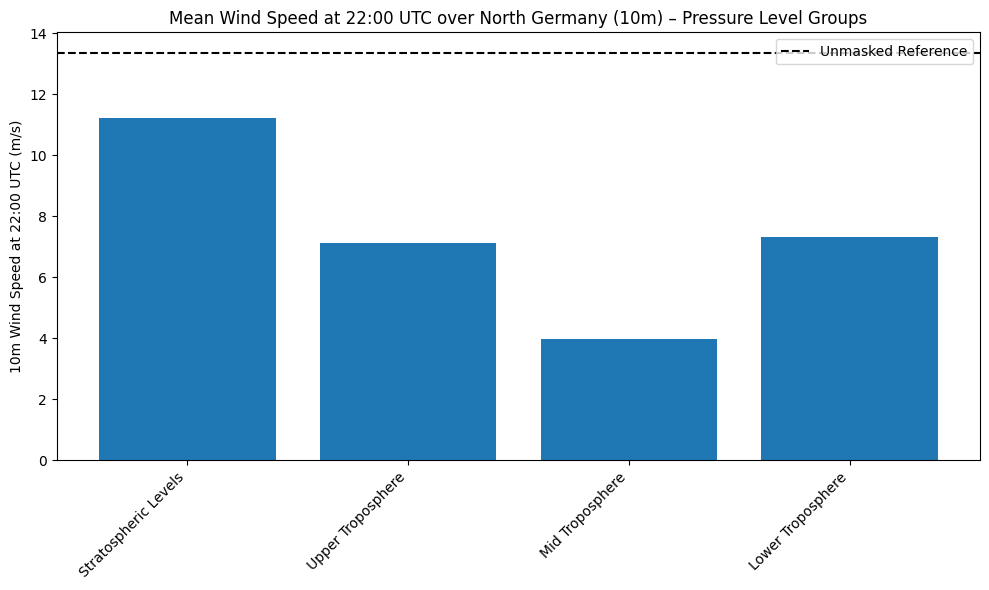

In [ ]:
rename_map = {
    "none_lev(50, 100, 150, 200)_regnone_tnone": "Stratospheric Levels",
    "none_lev(250, 300, 400)_regnone_tnone": "Upper Troposphere",
    "none_lev(500, 600, 700)_regnone_tnone": "Mid Troposphere",
    "none_lev(850, 925, 1000)_regnone_tnone": "Lower Troposphere"
}

plot_mean_wind_speed_comparison_feature_occlusion(
    masked_folder="../data/feature_occlusion/pressure_level_groups",
    input_path=original_prediction_path,
    title="Mean Wind Speed at 22:00 UTC over North Germany (10m) – Pressure Level Groups",
    rename_map=rename_map,
    order=[
        "Stratospheric Levels",
        "Upper Troposphere",
        "Mid Troposphere",
        "Lower Troposphere"
    ]
)

/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/plots/feature_occlusion_plots.py:57: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  unmasked_ds = xr.open_dataset(input_path)
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/plots/feature_occlusion_plots.py:73: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/plots/feature_occlusion_plots.py:73: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/Users/estakempf/Tech/Bachel

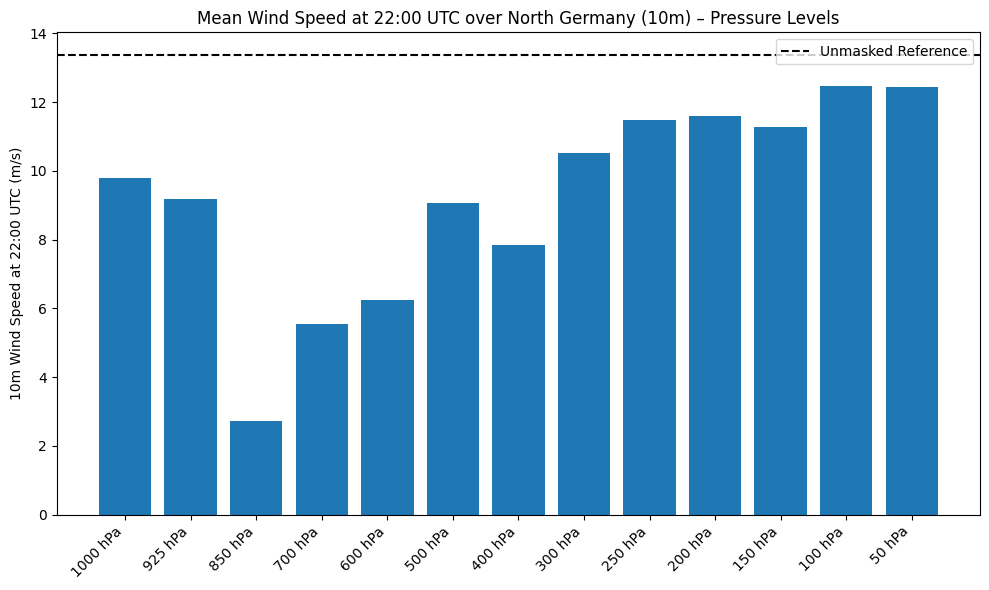

In [14]:
rename_map = {
    "none_lev1000_regnone_tnone": "1000 hPa",
    "none_lev925_regnone_tnone": "925 hPa",
    "none_lev850_regnone_tnone": "850 hPa",
    "none_lev700_regnone_tnone": "700 hPa",
    "none_lev600_regnone_tnone": "600 hPa",
    "none_lev500_regnone_tnone": "500 hPa",
    "none_lev400_regnone_tnone": "400 hPa",
    "none_lev300_regnone_tnone": "300 hPa",
    "none_lev250_regnone_tnone": "250 hPa",
    "none_lev200_regnone_tnone": "200 hPa",
    "none_lev150_regnone_tnone": "150 hPa",
    "none_lev100_regnone_tnone": "100 hPa",
    "none_lev50_regnone_tnone": "50 hPa"
}

plot_mean_wind_speed_comparison_feature_occlusion(
    masked_folder="../data/feature_occlusion/pressure_levels",
    input_path=original_prediction_path,
    title="Mean Wind Speed at 22:00 UTC over North Germany (10m) – Pressure Levels",
    rename_map=rename_map,
    order=[
        "1000 hPa",
        "925 hPa",
        "850 hPa",
        "700 hPa",
        "600 hPa",
        "500 hPa",
        "400 hPa",
        "300 hPa",
        "250 hPa",
        "200 hPa",
        "150 hPa",
        "100 hPa",
        "50 hPa"
    ]
)

/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/plots/feature_occlusion_plots.py:57: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  unmasked_ds = xr.open_dataset(input_path)
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/plots/feature_occlusion_plots.py:73: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/plots/feature_occlusion_plots.py:73: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/Users/estakempf/Tech/Bachel

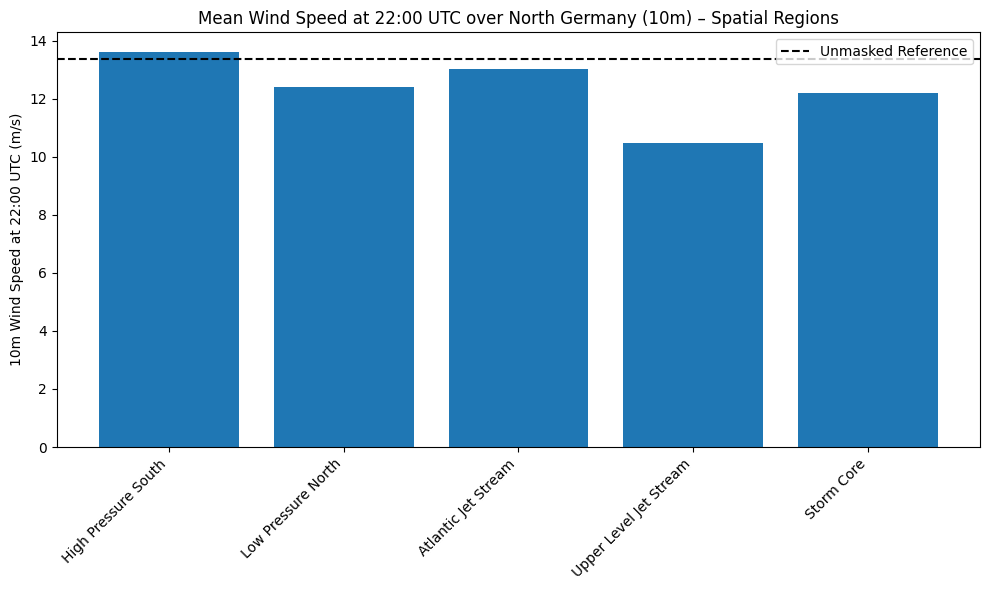

In [15]:
rename_map = {
    "none_levnone_regatlantic_jet_stream_tnone": "Atlantic Jet Stream",
    "none_levnone_reghigh_pressure_south_tnone": "High Pressure South",
    "none_levnone_reglow_pressure_north_tnone": "Low Pressure North",
    "none_levnone_regnorth_germany_tnone": "North Germany",
    "none_levnone_regstorm_core_10utc_tnone": "Storm Core at 10 UTC",
    "none_levnone_regstorm_core_16utc_tnone": "Storm Core at 16 UTC",
    "none_levnone_regstorm_region_tnone": "Storm Region",
    "none_levnone_reg('storm_core_10utc', 'storm_core_16utc')_tnone": "Storm Core at 10 and 16 UTC",
    "none_levnone_regstorm_core_tnone": "Storm Core",
    "none_levnone_regdynamic_uljs_tnone": "Upper Level Jet Stream",
    "none_levnone_regstorm_core_t0": "Storm Core T0",
    "none_levnone_regstorm_core_t1": "Storm Core T1"
}

plot_mean_wind_speed_comparison_feature_occlusion(
    masked_folder="../data/feature_occlusion/spatial_regions",
    input_path=original_prediction_path,
    title="Mean Wind Speed at 22:00 UTC over North Germany (10m) – Spatial Regions",
    rename_map=rename_map,
    order=[
        "High Pressure South",
        "Low Pressure North",
        "Atlantic Jet Stream",
        "Upper Level Jet Stream",
        "Storm Core"
    ]
)

/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/plots/feature_occlusion_plots.py:57: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  unmasked_ds = xr.open_dataset(input_path)
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/plots/feature_occlusion_plots.py:73: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/plots/feature_occlusion_plots.py:73: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)


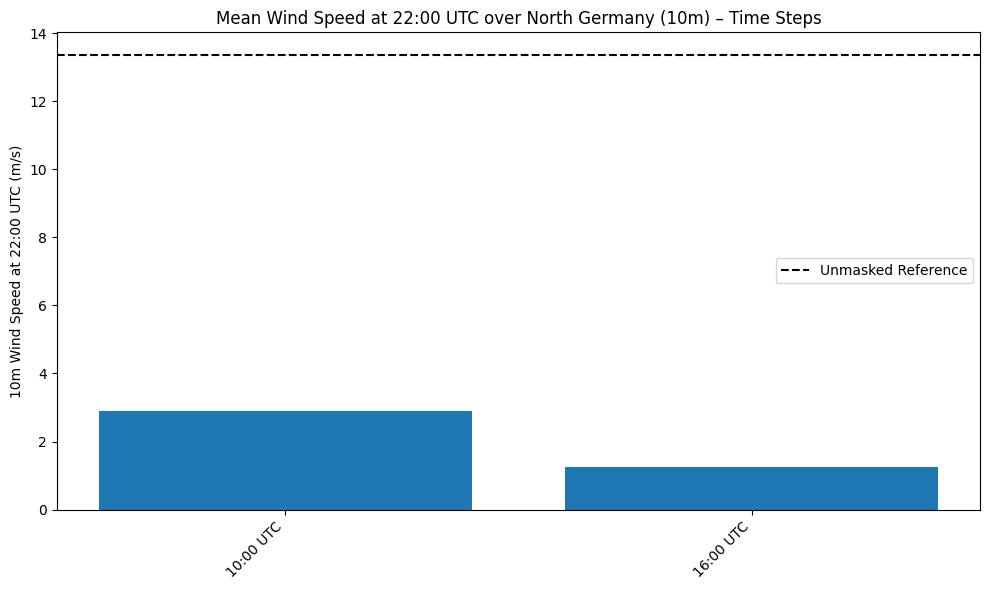

In [16]:
rename_map = {
    "none_levnone_regnone_t0": "10:00 UTC",
    "none_levnone_regnone_t1": "16:00 UTC",
}

plot_mean_wind_speed_comparison_feature_occlusion(
    masked_folder="../data/feature_occlusion/time_steps",
    input_path=original_prediction_path,
    title="Mean Wind Speed at 22:00 UTC over North Germany (10m) – Time Steps",
    rename_map=rename_map
)

## Multiple Features

/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/plots/feature_occlusion_plots.py:307: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  reference_ds = xr.open_dataset(reference_path)
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/plots/feature_occlusion_plots.py:324: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fname))
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/plots/feature_occlusion_plots.py:324: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_data

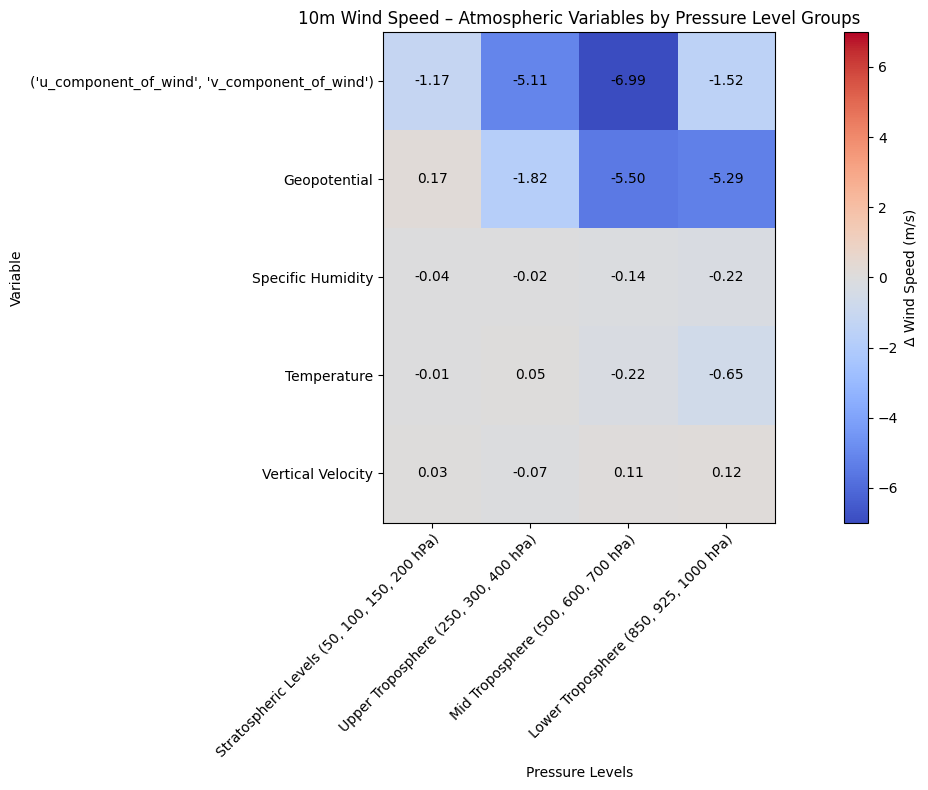

In [4]:
rename_map = {
    "geopotential": "Geopotential",
    "temperature": "Temperature",
    "specific_humidity": "Specific Humidity",
    # "u_component_of_wind": "U Wind",
    # "v_component_of_wind": "V Wind",
    "u_component_of_wind\nv_component_of_wind": "Wind Speed",
    "vertical_velocity": "Vertical Velocity",

    "50, 100, 150, 200": "Stratospheric Levels (50, 100, 150, 200 hPa)",
    "250, 300, 400": "Upper Troposphere (250, 300, 400 hPa)",
    "500, 600, 700": "Mid Troposphere (500, 600, 700 hPa)",
    "850, 925, 1000": "Lower Troposphere (850, 925, 1000 hPa)"
}

plot_feature_grouped_heatmap(
    masked_folder="../data/feature_occlusion/pressure_level_groups_atmospheric_variables",
    reference_path=original_prediction_path,
    group_x="Pressure Levels",
    group_y="Variable",
    title="10m Wind Speed – Atmospheric Variables by Pressure Level Groups",
    rename_map=rename_map,
    order={
        "Pressure Levels": [
            "Stratospheric Levels (50, 100, 150, 200 hPa)",
            "Upper Troposphere (250, 300, 400 hPa)",
            "Mid Troposphere (500, 600, 700 hPa)",
            "Lower Troposphere (850, 925, 1000 hPa)"
        ],
    }
)


/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_32308/10045735.py:53: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  reference_ds = xr.open_dataset(reference_path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_32308/10045735.py:70: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fname))
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_32308/10045735.py:70: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fnam

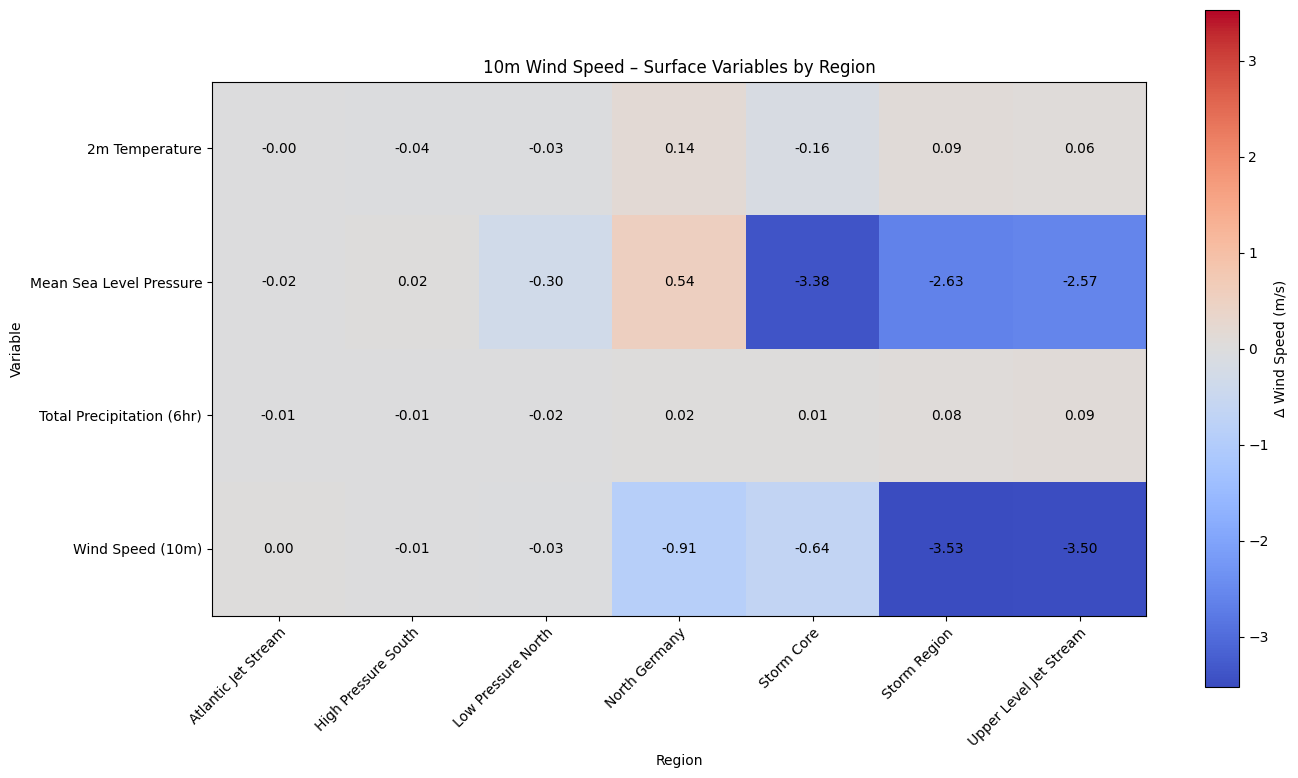

In [4]:
rename_map = {
    "2m_temperature_levnone": "2m Temperature",
    "mean_sea_level_pressure_levnone": "Mean Sea Level Pressure",
    "total_precipitation_6hr_levnone": "Total Precipitation (6hr)",
    "('10m_u_component_of_wind', '10m_v_component_of_wind')_levnone": "Wind Speed (10m)",

    "atlantic_jet_stream_tnone": "Atlantic Jet Stream",
    "high_pressure_south_tnone": "High Pressure South",
    "low_pressure_north_tnone": "Low Pressure North",
    "north_germany_tnone": "North Germany",
    "storm_core_10utc_tnone": "Storm Core at 10 UTC",
    "storm_core_16utc_tnone": "Storm Core at 16 UTC",
    "('storm_core_10utc', 'storm_core_16utc')": "Storm Core 10 and 16 UTC",
    "storm_region_tnone": "Storm Region",
    "storm_core_tnone": "Storm Core",
    "dynamic_uljs_tnone": "Upper Level Jet Stream"
}

plot_feature_grouped_heatmap(
    masked_folder="../data/feature_occlusion/regions_surface_variables",
    reference_path=original_prediction_path,
    group_x="Region",
    title="10m Wind Speed – Surface Variables by Region",
    rename_map=rename_map
)


/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_58297/10045735.py:53: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  reference_ds = xr.open_dataset(reference_path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_58297/10045735.py:70: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fname))
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_58297/10045735.py:70: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fnam

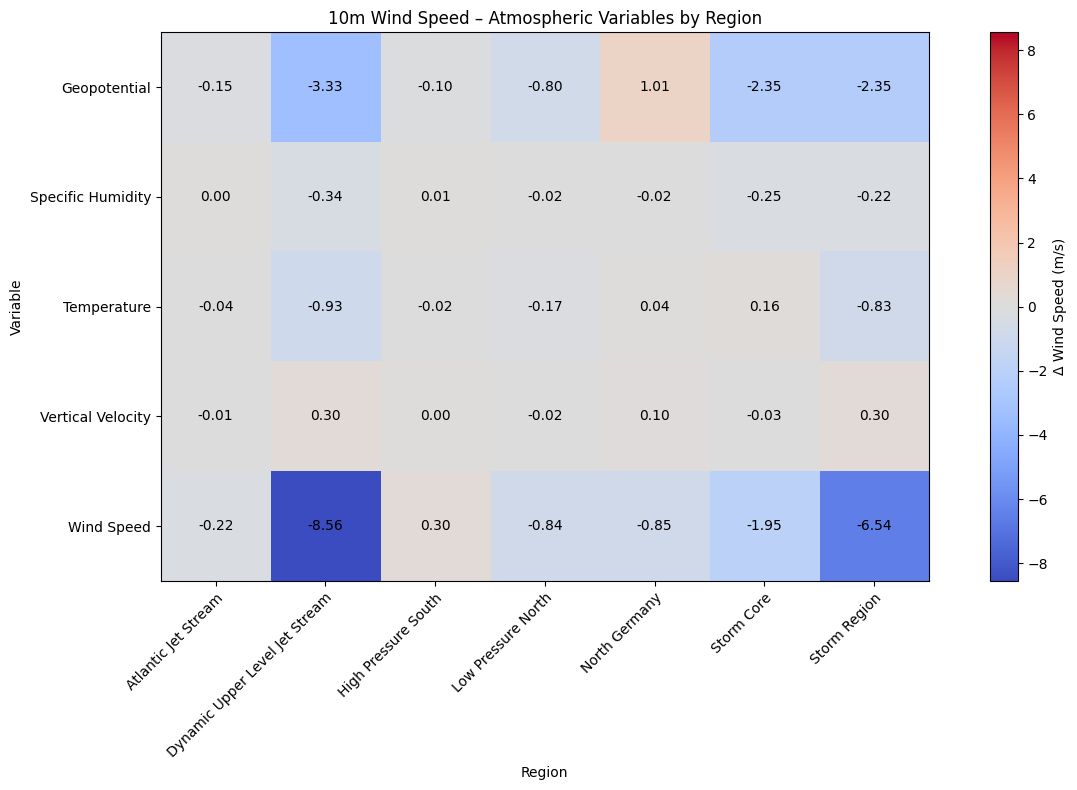

In [5]:
rename_map = {
    "geopotential_levnone": "Geopotential",
    "temperature_levnone": "Temperature",
    "specific_humidity_levnone": "Specific Humidity",
    "('u_component_of_wind', 'v_component_of_wind')_levnone": "Wind Speed",
    "vertical_velocity_levnone": "Vertical Velocity",
    "storm_core_tnone": "Storm Core",

    "atlantic_jet_stream_tnone": "Atlantic Jet Stream",
    "upper_level_jet_stream_tnone": "Upper Level Jet Stream",
    "high_pressure_south_tnone": "High Pressure South",
    "low_pressure_north_tnone": "Low Pressure North",
    "north_germany_tnone": "North Germany",
    "storm_region_tnone": "Storm Region",
    "dynamic_uljs_tnone": "Dynamic Upper Level Jet Stream"
}

plot_feature_grouped_heatmap(
    masked_folder="../data/feature_occlusion/regions_atmospheric_variables",
    reference_path=original_prediction_path,
    group_x="Region",
    title="10m Wind Speed – Atmospheric Variables by Region",
    rename_map=rename_map,
)


/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_58297/10045735.py:53: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  reference_ds = xr.open_dataset(reference_path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_58297/10045735.py:70: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fname))
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_58297/10045735.py:70: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fnam

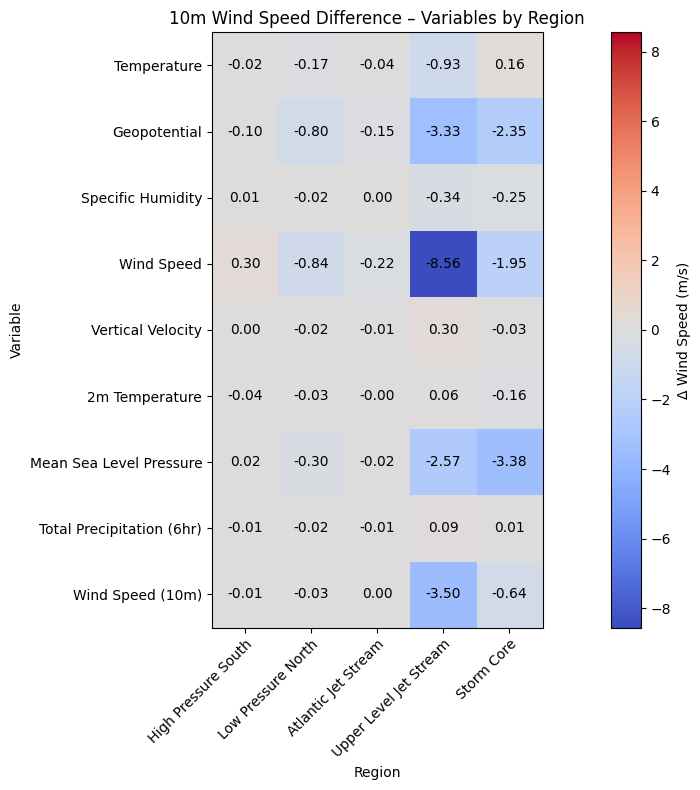

In [21]:
rename_map = {
    # Surface Variables
    "2m_temperature_levnone": "2m Temperature",
    "mean_sea_level_pressure_levnone": "Mean Sea Level Pressure",
    "total_precipitation_6hr_levnone": "Total Precipitation (6hr)",
    "('10m_u_component_of_wind', '10m_v_component_of_wind')_levnone": "Wind Speed (10m)",

    # Atmospheric Variables
    "geopotential_levnone": "Geopotential",
    "temperature_levnone": "Temperature",
    "specific_humidity_levnone": "Specific Humidity",
    "('u_component_of_wind', 'v_component_of_wind')_levnone": "Wind Speed",
    "vertical_velocity_levnone": "Vertical Velocity",

    # Regions
    "atlantic_jet_stream_tnone": "Atlantic Jet Stream",
    "high_pressure_south_tnone": "High Pressure South",
    "low_pressure_north_tnone": "Low Pressure North",
    "dynamic_uljs_tnone": "Upper Level Jet Stream",
    "storm_core_tnone": "Storm Core",
    "north_germany_tnone": "North Germany",
}

order = {
    "Region": [
        "High Pressure South",
        "Low Pressure North",
        "Atlantic Jet Stream",
        "Upper Level Jet Stream",
        "Storm Core",
        "North Germany"
    ],
    "Variable": [
        "Temperature",
        "Geopotential",
        "Specific Humidity",
        "Wind Speed",
        "Vertical Velocity",

        "2m Temperature",
        "Mean Sea Level Pressure",
        "Total Precipitation (6hr)",
        "Wind Speed (10m)"
    ]
}

plot_feature_grouped_heatmap(
    masked_folder="../data/feature_occlusion/region_variables_heatmap_bt",
    reference_path=original_prediction_path,
    group_x="Region",
    title="10m Wind Speed Difference – Variables by Region",
    rename_map=rename_map,
    order=order
)

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_77101/10045735.py:53: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  reference_ds = xr.open_dataset(reference_path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_77101/10045735.py:70: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fname))
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_77101/10045735.py:70: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fnam

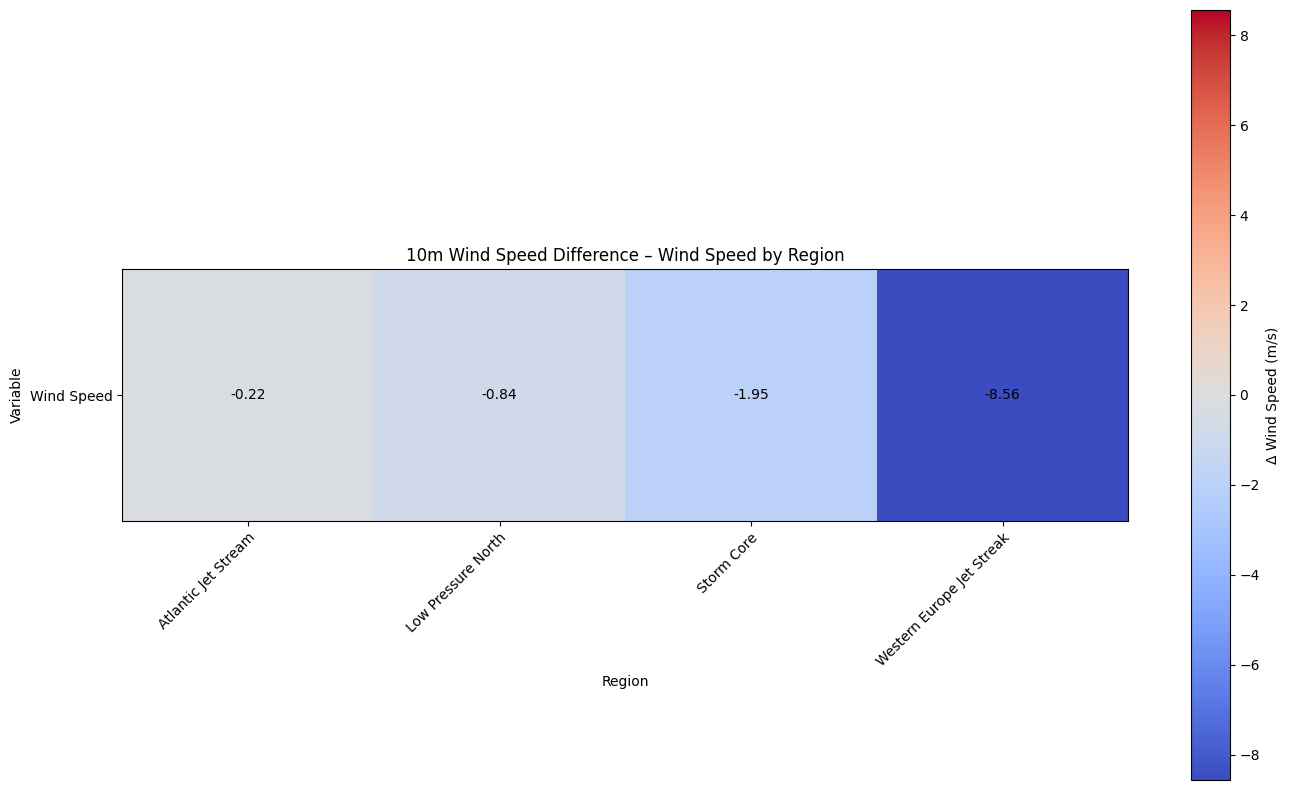

In [6]:
rename_map = {
    # Surface Variables
    "2m_temperature_levnone": "2m Temperature",
    "mean_sea_level_pressure_levnone": "Mean Sea Level Pressure",
    "total_precipitation_6hr_levnone": "Total Precipitation (6hr)",
    "('10m_u_component_of_wind', '10m_v_component_of_wind')_levnone": "Wind Speed (10m)",

    # Atmospheric Variables
    "geopotential_levnone": "Geopotential",
    "temperature_levnone": "Temperature",
    "specific_humidity_levnone": "Specific Humidity",
    "('u_component_of_wind', 'v_component_of_wind')_levnone": "Wind Speed",
    "vertical_velocity_levnone": "Vertical Velocity",

    # Regions
    "atlantic_jet_stream_tnone": "Atlantic Jet Stream",
    "high_pressure_south_tnone": "High Pressure South",
    "low_pressure_north_tnone": "Low Pressure North",
    "dynamic_uljs_tnone": "Western Europe Jet Streak",
    "storm_core_tnone": "Storm Core",
}

order = {
    "Region": [
        "Atlantic Jet Stream",
        "Low Pressure North",
        "Storm Core",
        "Western Europe Jet Streak"
    ],
    "Variable": [
        "Wind Speed"
    ]
}

plot_feature_grouped_heatmap(
    masked_folder="../data/feature_occlusion/region_variables_heatmap_bt",
    reference_path=original_prediction_path,
    group_x="Region",
    title="10m Wind Speed Difference – Wind Speed by Region",
    rename_map=rename_map,
    order=order
)

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_32308/10045735.py:53: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  reference_ds = xr.open_dataset(reference_path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_32308/10045735.py:70: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fname))
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_32308/10045735.py:70: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fnam

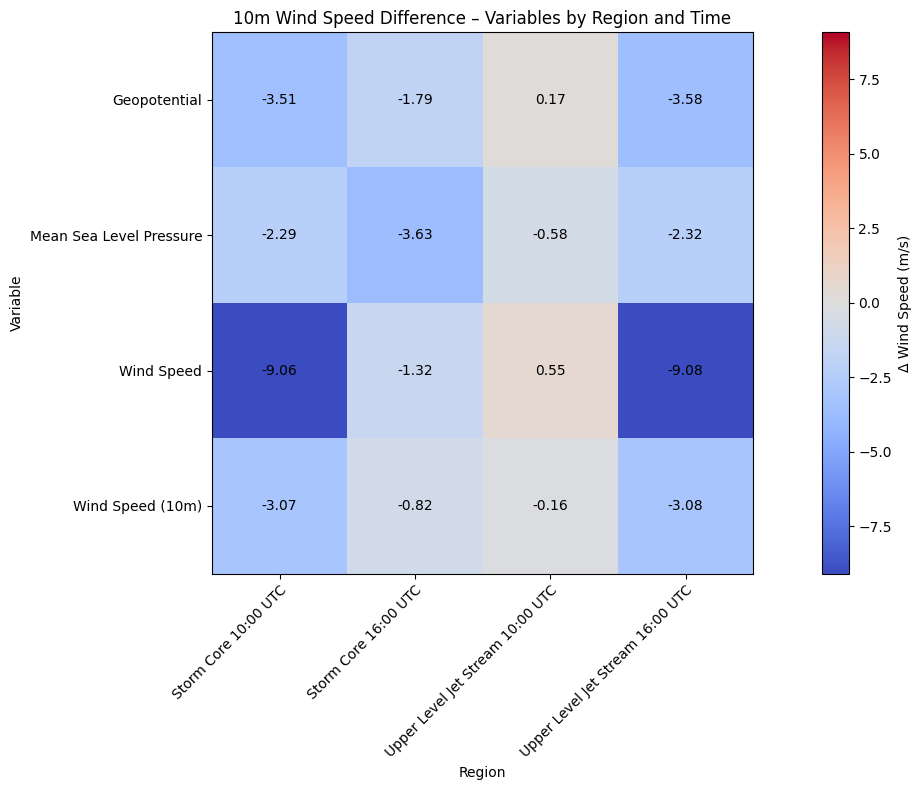

In [17]:
rename_map = {
    # Surface Variables
    "mean_sea_level_pressure_levnone": "Mean Sea Level Pressure",
    "('10m_u_component_of_wind', '10m_v_component_of_wind')_levnone": "Wind Speed (10m)",

    # Atmospheric Variables
    "geopotential_levnone": "Geopotential",
    "('u_component_of_wind', 'v_component_of_wind')_levnone": "Wind Speed",

    # Regions
    "dynamic_uljs_t0": "Upper Level Jet Stream 10:00 UTC",
    "dynamic_uljs_t1": "Upper Level Jet Stream 16:00 UTC",
    "storm_core_t0": "Storm Core 10:00 UTC",
    "storm_core_t1": "Storm Core 16:00 UTC",
}

plot_feature_grouped_heatmap(
    masked_folder="../data/feature_occlusion/selected_regions_variables_time",
    reference_path=original_prediction_path,
    group_x="Region",
    title="10m Wind Speed Difference – Variables by Region and Time",
    rename_map=rename_map,
)

/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/plots/feature_occlusion_plots.py:438: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  reference_ds = xr.open_dataset(reference_path)
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/plots/feature_occlusion_plots.py:455: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fname))
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/plots/feature_occlusion_plots.py:455: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_data

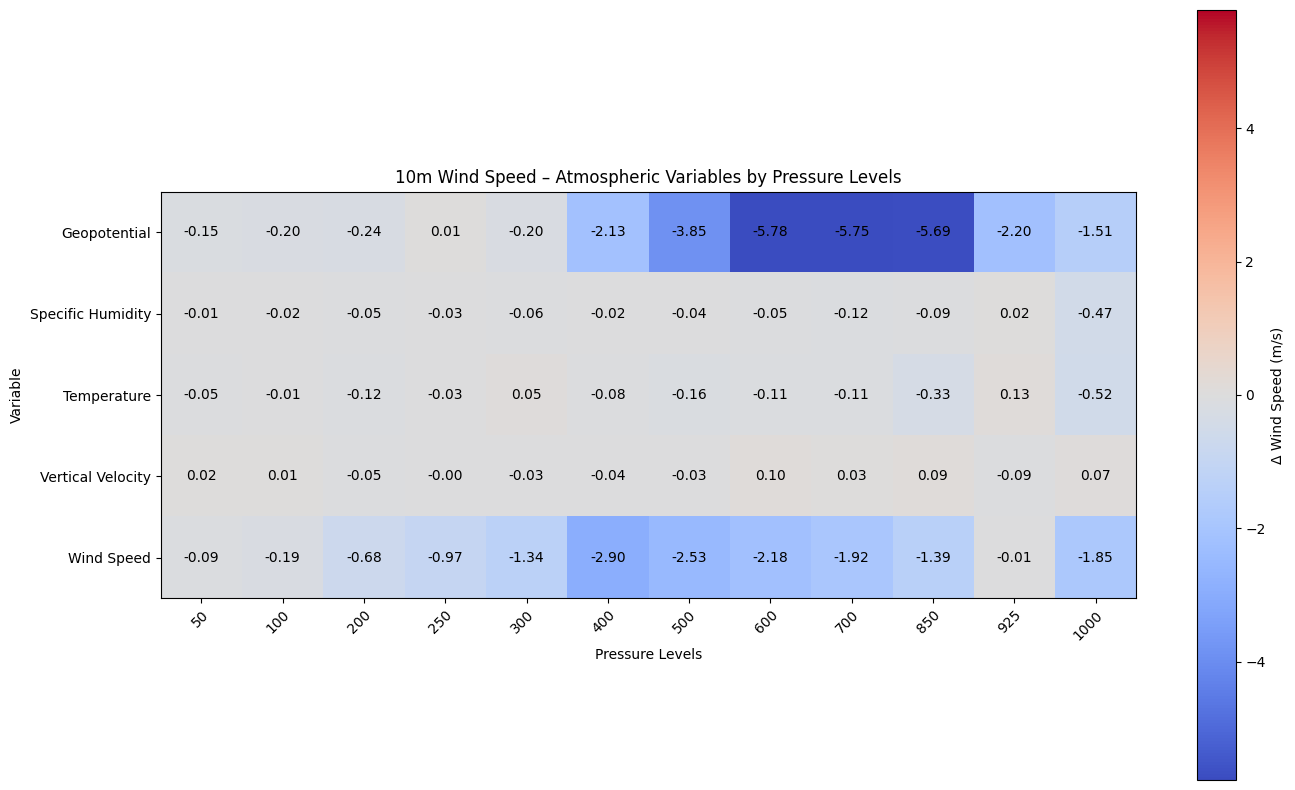

In [8]:
rename_map = {
    "geopotential": "Geopotential",
    "temperature": "Temperature",
    "specific_humidity": "Specific Humidity",
    "('u_component_of_wind', 'v_component_of_wind')": "Wind Speed",
    "vertical_velocity": "Vertical Velocity",
}

order = {
    "Pressure Levels": [
        "50",
        "100",
        "150 ",
        "200",
        "250",
        "300",
        "400",
        "500",
        "600",  
        "700",  
        "850",
        "925",
        "1000"
    ],
}

plot_feature_grouped_heatmap_special_for_pressure_level(
    masked_folder="../data/feature_occlusion/atmospheric_variables_levels",
    reference_path=original_prediction_path,
    group_x="Pressure Levels",
    group_y="Variable",
    title="10m Wind Speed – Atmospheric Variables by Pressure Levels",
    rename_map=rename_map,
    order=order
)
